Axel Daniel Nuño Arrieta | T035859

En esta actividad vamos a trabajar con PyTorch para resolver un problema de clasificación multiclase usando CIFAR-10. Aquí no solo entrenemos una red neuronal convolucional, sino que comparemos tres arquitecturas distintas manteniendo iguales los demás hiperparámetros. Además, importaremos las librerías necesarias para cargar los datos, transformarlos a tensores, entrenar los modelos, evaluar su rendimiento y visualizar sus curvas de aprendizaje.

In [1]:
import os
import copy
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

Ahora vamos a cargar CIFAR-10 directamente desde torchvision. Este dataset ya viene dividido en entrenamiento y prueba, así que no hace falta generar un conjunto de validación adicional. Un detalle importante es que las imágenes originalmente pueden cargarse como objetos tipo PIL, por lo que necesitamos convertirlas a tensores para que PyTorch pueda procesarlas correctamente. Para eso usaremos transforms.ToTensor(), que además deja los valores de los píxeles en un rango adecuado para el entrenamiento.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

classes = train_dataset.classes

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

len(train_dataset), len(test_dataset), classes

100%|██████████| 170M/170M [03:36<00:00, 786kB/s]  
/Users/dnuno/Documents/INTELIGENCIA-COMPUTACIONAL/INTELIGENCIA-COMPUTACIONAL/RD-CV-PYTORCH/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(50000,
 10000,
 ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'])

Antes de entrenar cualquier modelo, vamos inspeccionar algunas imágenes del dataset para confirmar que todo se cargó correctamente.

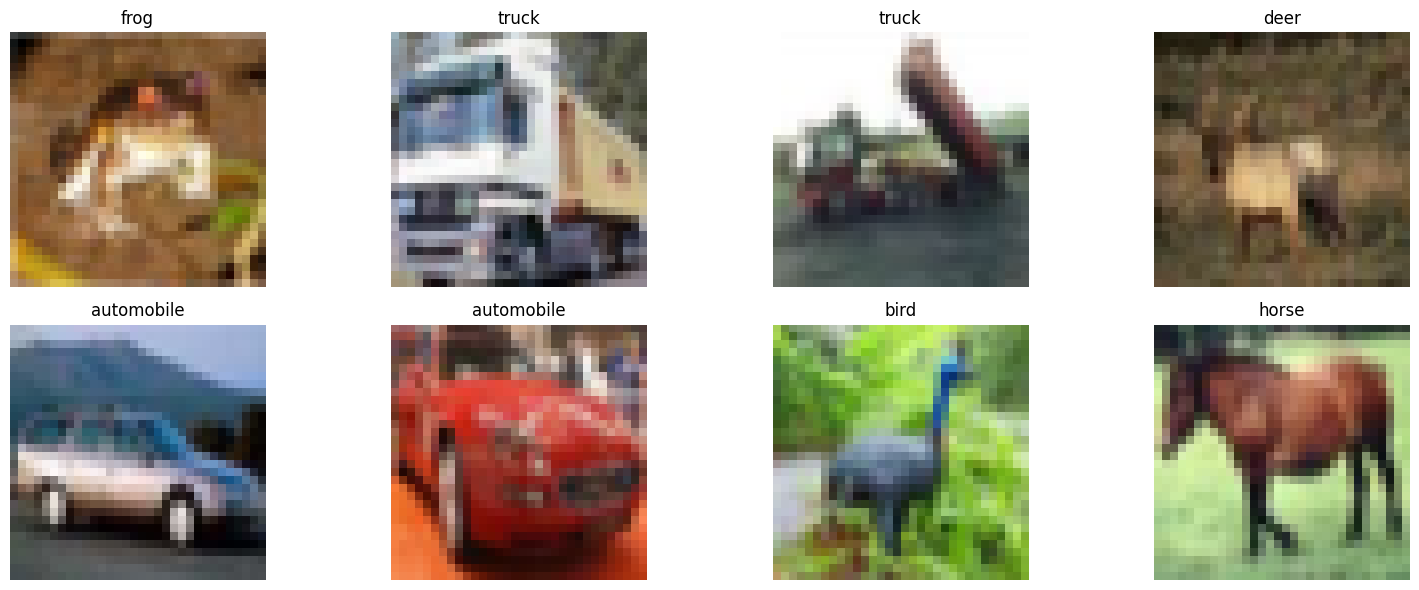

In [3]:
def show_images(dataset, class_names, num_images=8):
    fig, axes = plt.subplots(2, num_images // 2, figsize=(16, 6))
    axes = axes.flatten()
    for i in range(num_images):
        image, label = dataset[i]
        axes[i].imshow(image.permute(1, 2, 0))
        axes[i].set_title(class_names[label])
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_images(train_dataset, classes, num_images=8)

Enseguida vamos a definir tres redes neuronales convolucionales distintas.

In [4]:
class CNNModel1(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CNNModel2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CNNModel3(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Como estamos resolviendo un problema de clasificación multiclase, vamos a usar CrossEntropyLoss, que es una función de pérdida. También vamos a fijar los hiperparámetros base que se mantendrán iguales para los tres modelos.

In [5]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.001
num_epochs = 10

Ahora vamos a implementar la parte más importante, las funciones de evaluación y entrenamiento.

In [6]:
def calculate_accuracy(outputs, labels):
    predictions = torch.argmax(outputs, dim=1)
    correct = (predictions == labels).sum().item()
    return correct / labels.size(0)


def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs):
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_samples = 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", leave=False)

        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            running_correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
            running_samples += images.size(0)

        train_loss = running_loss / running_samples
        train_acc = running_correct / running_samples
        test_loss, test_acc = evaluate_model(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    return history

Con toda la base lista, vamos a entrenar el primer modelo. Este modelo funciona como una referencia inicial y nos ayuda a tener un punto de comparación claro.

In [7]:
model1 = CNNModel1().to(device)
optimizer1 = optim.Adam(model1.parameters(), lr=learning_rate)
history1 = train_model(model1, train_loader, test_loader, criterion, optimizer1, num_epochs)

Epoch 1/10 | Train Loss: 1.5950 | Train Acc: 0.4299 | Test Loss: 1.3443 | Test Acc: 0.5168


Epoch 2/10 | Train Loss: 1.2243 | Train Acc: 0.5657 | Test Loss: 1.1601 | Test Acc: 0.5827


Epoch 3/10 | Train Loss: 1.0664 | Train Acc: 0.6251 | Test Loss: 1.0111 | Test Acc: 0.6495


Epoch 4/10 | Train Loss: 0.9711 | Train Acc: 0.6604 | Test Loss: 0.9960 | Test Acc: 0.6521


Epoch 5/10 | Train Loss: 0.8984 | Train Acc: 0.6850 | Test Loss: 0.9338 | Test Acc: 0.6787


Epoch 6/10 | Train Loss: 0.8365 | Train Acc: 0.7082 | Test Loss: 0.8960 | Test Acc: 0.6909


Epoch 7/10 | Train Loss: 0.7788 | Train Acc: 0.7270 | Test Loss: 0.8906 | Test Acc: 0.6938


Epoch 8/10 | Train Loss: 0.7292 | Train Acc: 0.7455 | Test Loss: 0.8925 | Test Acc: 0.6955


Epoch 9/10 | Train Loss: 0.6814 | Train Acc: 0.7614 | Test Loss: 0.8852 | Test Acc: 0.7045


Epoch 10/10 | Train Loss: 0.6399 | Train Acc: 0.7761 | Test Loss: 0.8745 | Test Acc: 0.7089


ahora vamos a entrenar el segundo modelo. Aquí la red tiene más capas convolucionales que la anterior, por lo que en teoría puede aprender representaciones visuales más ricas.

In [8]:
model2 = CNNModel2().to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=learning_rate)
history2 = train_model(model2, train_loader, test_loader, criterion, optimizer2, num_epochs)

Epoch 1/10 | Train Loss: 1.6067 | Train Acc: 0.4174 | Test Loss: 1.2907 | Test Acc: 0.5399


Epoch 2/10 | Train Loss: 1.1540 | Train Acc: 0.5906 | Test Loss: 1.0368 | Test Acc: 0.6301


Epoch 3/10 | Train Loss: 0.9422 | Train Acc: 0.6672 | Test Loss: 0.9209 | Test Acc: 0.6765


Epoch 4/10 | Train Loss: 0.7916 | Train Acc: 0.7237 | Test Loss: 0.8566 | Test Acc: 0.7037


Epoch 5/10 | Train Loss: 0.6698 | Train Acc: 0.7643 | Test Loss: 0.7974 | Test Acc: 0.7244


Epoch 6/10 | Train Loss: 0.5638 | Train Acc: 0.8054 | Test Loss: 0.8007 | Test Acc: 0.7300


Epoch 7/10 | Train Loss: 0.4590 | Train Acc: 0.8390 | Test Loss: 0.8688 | Test Acc: 0.7291


Epoch 8/10 | Train Loss: 0.3612 | Train Acc: 0.8735 | Test Loss: 0.9052 | Test Acc: 0.7289


Epoch 9/10 | Train Loss: 0.2763 | Train Acc: 0.9034 | Test Loss: 1.0136 | Test Acc: 0.7322


Epoch 10/10 | Train Loss: 0.2008 | Train Acc: 0.9298 | Test Loss: 1.1344 | Test Acc: 0.7146


Finalmente vamos a entrenar el tercer modelo. Esta arquitectura incluye batch normalization y dropout, dos elementos que suelen ayudar mucho a estabilizar el aprendizaje y a reducir el sobreajuste. En muchos casos, este tipo de modelo logra un desempeño más consistente, así que será interesante ver si aquí también termina siendo el más fuerte de los tres

In [9]:
model3 = CNNModel3().to(device)
optimizer3 = optim.Adam(model3.parameters(), lr=learning_rate)
history3 = train_model(model3, train_loader, test_loader, criterion, optimizer3, num_epochs)

Epoch 1/10 | Train Loss: 1.4478 | Train Acc: 0.4863 | Test Loss: 1.0239 | Test Acc: 0.6370


Epoch 2/10 | Train Loss: 1.0441 | Train Acc: 0.6348 | Test Loss: 0.8850 | Test Acc: 0.6836


Epoch 3/10 | Train Loss: 0.8819 | Train Acc: 0.6953 | Test Loss: 0.7758 | Test Acc: 0.7311


Epoch 4/10 | Train Loss: 0.7909 | Train Acc: 0.7270 | Test Loss: 0.7182 | Test Acc: 0.7491


Epoch 5/10 | Train Loss: 0.7223 | Train Acc: 0.7476 | Test Loss: 0.7297 | Test Acc: 0.7511


Epoch 6/10 | Train Loss: 0.6686 | Train Acc: 0.7683 | Test Loss: 0.6665 | Test Acc: 0.7740


Epoch 7/10 | Train Loss: 0.6107 | Train Acc: 0.7875 | Test Loss: 0.6679 | Test Acc: 0.7843


Epoch 8/10 | Train Loss: 0.5677 | Train Acc: 0.8029 | Test Loss: 0.6397 | Test Acc: 0.7892


Epoch 9/10 | Train Loss: 0.5314 | Train Acc: 0.8147 | Test Loss: 0.6515 | Test Acc: 0.7897


Epoch 10/10 | Train Loss: 0.4965 | Train Acc: 0.8256 | Test Loss: 0.7129 | Test Acc: 0.7860


Una vez que los tres modelos terminaron de entrenarse, vamos a visualizar sus curvas de aprendizaje.

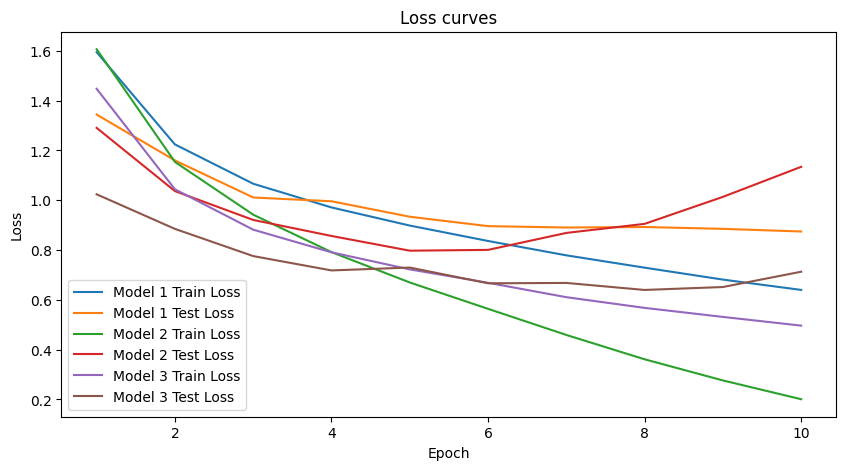

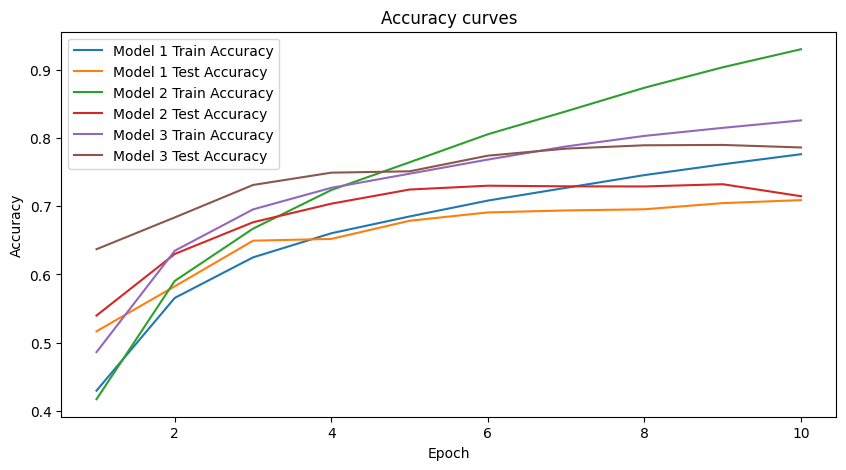

In [10]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history1["train_loss"], label="Model 1 Train Loss")
plt.plot(epochs_range, history1["test_loss"], label="Model 1 Test Loss")
plt.plot(epochs_range, history2["train_loss"], label="Model 2 Train Loss")
plt.plot(epochs_range, history2["test_loss"], label="Model 2 Test Loss")
plt.plot(epochs_range, history3["train_loss"], label="Model 3 Train Loss")
plt.plot(epochs_range, history3["test_loss"], label="Model 3 Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history1["train_acc"], label="Model 1 Train Accuracy")
plt.plot(epochs_range, history1["test_acc"], label="Model 1 Test Accuracy")
plt.plot(epochs_range, history2["train_acc"], label="Model 2 Train Accuracy")
plt.plot(epochs_range, history2["test_acc"], label="Model 2 Test Accuracy")
plt.plot(epochs_range, history3["train_acc"], label="Model 3 Train Accuracy")
plt.plot(epochs_range, history3["test_acc"], label="Model 3 Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves")
plt.legend()
plt.show()

Ahora vamos a comparar formalmente los tres modelos y seleccionar el mejor en función del accuracy obtenido en test.

In [11]:
final_results = {
    "Model 1": history1["test_acc"][-1],
    "Model 2": history2["test_acc"][-1],
    "Model 3": history3["test_acc"][-1]
}

final_results

{'Model 1': 0.7089, 'Model 2': 0.7146, 'Model 3': 0.786}

Con los resultados finales ya calculados, vamos a escoger el mejor modelo automáticamente.

In [12]:
best_model_name = max(final_results, key=final_results.get)

if best_model_name == "Model 1":
    best_model = model1
    best_history = history1
elif best_model_name == "Model 2":
    best_model = model2
    best_history = history2
else:
    best_model = model3
    best_history = history3

best_model_name, final_results[best_model_name]

('Model 3', 0.786)

Ahora vamos a hacer la evaluación final del mejor modelo. Aunque ya fuimos calculando métricas al final de cada época, aquí dejamos explícitamente el accuracy final del modelo ganador sobre el conjunto de test. Esto cumple con el criterio de seleccionar y evaluar el mejor modelo obtenido.

In [13]:
best_test_loss, best_test_acc = evaluate_model(best_model, test_loader, criterion)

print("Best model:", best_model_name)
print("Test loss:", round(best_test_loss, 4))
print("Test accuracy:", round(best_test_acc, 4))

Best model: Model 3
Test loss: 0.7129
Test accuracy: 0.786


También es útil conocer cuántos parámetros entrenables tiene cada arquitectura. Eso nos ayuda a contextualizar mejor los resultados, porque no siempre un modelo con más parámetros termina siendo mucho mejor.

In [14]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model 1 parameters:", count_parameters(model1))
print("Model 2 parameters:", count_parameters(model2))
print("Model 3 parameters:", count_parameters(model3))

Model 1 parameters: 545098
Model 2 parameters: 1116970
Model 3 parameters: 2193674


Para los puntos extra, vamos a implementar una función que reciba la ruta de una imagen en disco, la procese de forma compatible con el modelo y regrese la etiqueta predicha en texto.

In [15]:
inference_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

def predict_image(image_path, model, class_names, device):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = inference_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        predicted_class = torch.argmax(outputs, dim=1).item()

    return class_names[predicted_class]

Con la función anterior ya lista, ahora dejamos un ejemplo de uso.

In [ ]:
image_path = "prueba.png"
print(predict_image(image_path, best_model, classes, device))

horse


Esta actividad me ayudó a entender de forma más práctica cómo se entrena una red neuronal convolucional para clasificación de imágenes. Aunque en teoría la idea de una CNN puede parecer directa, al implementarla paso por paso se vuelve mucho más claro cómo influyen detalles como la arquitectura, la cantidad de capas y el uso de técnicas como batch normalization o dropout.